<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/Homework2026/2026/HW/brendanperez/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kirchhoff's Laws and Linear Algebra: Solving Circuit Networks

## Coding

## Homework (total 42 points)

Make sure that all the code you are writing has proper docstrings.

### Part 1: Bridge Circuit (32 points)

A bridge is a classic circuit used to measure unknown resistances with high precision.

```
     B ---/\/\/--- C--(-)
     |\     R₄     |
     | \           |
     R₃ \__R₅ __   R₂
     |          \  |
     |      R₁   \ |         
(+)--A ---/\/\/--- D

```

- $V_0$: voltage source between A and C
- $R_1, R_2, R_3, R_4$: bridge resistors
- $R_5$: galvanometer (bridge resistor between B and D)

#### Tasks:

1. **Set up the equations** (10 points)  
   Write a function `build_system(V0, R1, R2, R3, R4, R5)` that returns the coefficient matrix $A$ and the right-hand-side vector $\vec{b}$ for the bridge circuit using Kirchhoff's laws. Your function should return both `A` and `b`.

2. **Solve and verify** (10 points)  
   Write a function `solve_circuit(A, b)` that solves the system and returns all branch currents. Test it with $V_0 = 10$ V, $R_1 = 100 \ \Omega$, $R_2 = 200 \ \Omega$, $R_3 = 300 \ \Omega$, $R_4 = 600 \ \Omega$, $R_5 = 50 \ \Omega$.  
   Verify your result using a power balance check.

3. **Balanced bridge condition** (12 points)  
   A circuit bridge is *balanced* when no current flows through $R_5$ (the galvanometer), which happens when:
   $$\frac{R_1}{R_3} = \frac{R_2}{R_4}$$
   - Write a function that takes the four bridge resistors and checks whether the bridge is balanced.  

In [20]:
#import libraries
import numpy as np

In [23]:
def build_system(V0, R1, R2, R3, R4, R5):

  """

  Returns the coefficient matrix A, and right-hand-side vector b for a
  five resistor bridge circut

  We form the matricies by applying Kirchoff's Laws to the circut.

  Parameters:
  ----------------------
  V0: float
    voltage of the source (V)
  R1, R2, R3, R4, R5: float
    Resistance of the five resistors (Ohm)

  Returns:
  ----------------------
  A: np.ndarray
    Coefficient Matrix
  b: np.ndarray
    Vector matrix

     B ---/\\/\\/--- C--(-)
     |\\     R₄     |
     | \\           |
     R₃ \\__R₅ __   R₂
     |          \\  |
     |      R₁   \\ |
(+)--A ---/\\/\\/--- D


  We have five currents

  I1 through R1
  I2 through R2
  I3 through R3
  I4 through R4
  I5 through R5

  Using Kirchoff's Laws

  0=I1-I2+R5 (KCL at node D)
  0=-I3+I4-I5 (KCL at node B)
  V0=R1I1+R2I2 (Right Side Loop)
  V0=R3I3+R4I4 (Left Side Loop)
  0=-R1I1+R3I3-R5I5 (Loop Including Bridge)

  """
  A = np.array([[1, -1, 0, 0, 1],
                [0, 0, -1, 1, -1],
                [R1, R2, 0, 0, 0],
                [0, 0, R3, R4, 0],
                [-R1, 0, R3, 0, -R5]],dtype=float)

  b = np.array([0, 0, V0, V0, 0])

  return(A,b)

In [24]:
def solve_circut(A,b):
  currents = np.linalg.solve(A,b)
  return(currents)

In [32]:
#Testing The Two Functions
V0 = 10
R1 = 100
R2 = 200
R3 = 300
R4 = 600
R5 = 50

C = build_system(V0, R1, R2, R3, R4, R5)
A = C[0]
b= C[1]

print("A: ", A)
print("b: ", b)

currents = solve_circut(A,b)

print("I1 through R1 is {:.3f} A".format(currents[0]))
print("I2 through R2 is {:.3f} A".format(currents[1]))
print("I3 through R3 is {:.3f} A".format(currents[2]))
print("I4 through R4 is {:.3f} A".format(currents[3]))
print("I5 through R5 is {:.3f} A".format(currents[4]))


A:  [[   1.   -1.    0.    0.    1.]
 [   0.    0.   -1.    1.   -1.]
 [ 100.  200.    0.    0.    0.]
 [   0.    0.  300.  600.    0.]
 [-100.    0.  300.    0.  -50.]]
b:  [ 0  0 10 10  0]
I1 through R1 is 0.033 A
I2 through R2 is 0.033 A
I3 through R3 is 0.011 A
I4 through R4 is 0.011 A
I5 through R5 is 0.000 A


In [28]:
def isBalanced(R1, R2, R3, R4):
  if (R3 == 0 or R4 == 0): # Avoid divide by zero
    return(-1)
  if (R1/R3 == R2/R4):
    return(True)
  return(False)

In [33]:
print(isBalanced(R1,R2,R3,R4))

True


### Part 2: AI Creativity (10 points)

Use the following prompt in your favorite AI tool:

> I have a circuit with resistors and voltage sources that I solve using Kirchhoff's laws and linear algebra in Python. Give me a creative way to extend this circuit — for example adding capacitors, inductors, or building a practical application like a filter, sensor bridge, or measurement device. Show me how to set up and solve the equations in a Jupyter notebook. Then ask me if the circuit makes physical sense. Take my answer and adapt the model accordingly, updating the code. Repeat this until I'm confident the circuit could work in the real world.

Copy and run the final code in the cell below. Then comment on:
- How your AI model handled the physics (did it get the equations right on the first try?)

I used ChatGPT as my model, the equations seem to be correct and worked first try

- How many iteration steps it needed to arrive at a physically realistic circuit

It took a couple iterations, just to get better formatting of the code and equations

- Where in nature or engineering you would find the final circuit

You would see this filter in signal conditioning, to remove high frequency noise

## Solving the RC Circuit Using Kirchhoff’s Laws

### Circuit Description
The circuit consists of:
- A time-varying voltage source $( V_{in}(t) )$
- A resistor $( R )$ connected from the source to a node
- A capacitor $( C )$ connected from that node to ground
- The output voltage $( V_{out}(t) )$ measured across the capacitor

This configuration forms a first-order RC low-pass filter.

---

### Step 1: Apply Kirchhoff’s Current Law (KCL)

At the node between the resistor and capacitor, the sum of currents must be zero.

$$
I_R = I_C
$$

---

### Step 2: Express the currents

**Resistor current (Ohm’s Law):**
$$
I_R = \frac{V_{in}(t) - V_{out}(t)}{R}
$$

**Capacitor current (constitutive relation):**
$$
I_C = C \frac{dV_{out}}{dt}
$$

---

### Step 3: Form the governing equation

Setting the currents equal:
$$
\frac{V_{in}(t) - V_{out}(t)}{R} = C \frac{dV_{out}}{dt}
$$

Rearranging:
$$
\frac{dV_{out}}{dt} = \frac{1}{RC}\left(V_{in}(t) - V_{out}(t)\right)
$$

This is a first-order linear differential equation describing the circuit’s dynamics.

---

### Step 4: Initial condition

The capacitor voltage must be specified at \( t = 0 \):

$$
V_{out}(0) = V_C(0)
$$

In the simulation, this is typically set to:
$$
V_{out}(0) = 0 \ \text{V}
$$

---

### Step 5: Interpretation

- The time constant of the circuit is $( \tau = RC )$
- Rapid changes in $( V_{in}(t) )$ are attenuated
- Slow changes pass through with little distortion

This equation is solved numerically in Python using an ODE solver.

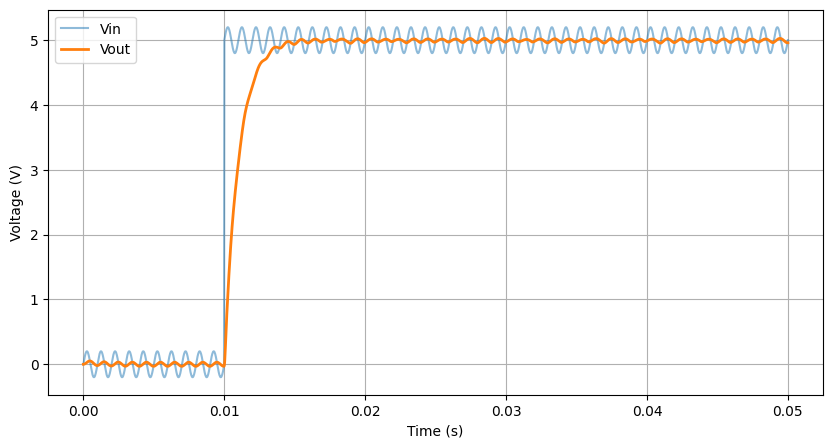

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Circuit parameters ---
R = 1_000        # Ohms
C = 1e-6         # Farads

# --- Input voltage source ---
def Vin(t):
    # Step input + high-frequency noise
    return 5.0 * (t >= 0.01) + 0.2 * np.sin(2 * np.pi * 1000 * t)

# --- RC filter differential equation (KCL) ---
def rc_filter(t, Vout):
    return (Vin(t) - Vout) / (R * C)

# --- Time span ---
t_span = (0, 0.05)
t_eval = np.linspace(*t_span, 2000)

# --- Solve ODE ---
solution = solve_ivp(
    rc_filter,
    t_span,
    y0=[0.0],          # initial capacitor voltage
    t_eval=t_eval
)

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(t_eval, [Vin(t) for t in t_eval], label="Vin", alpha=0.5)
plt.plot(t_eval, solution.y[0], label="Vout", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# this installs a new library
!pip install schemdraw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.4/148.4 kB 5.6 MB/s eta 0:00:00


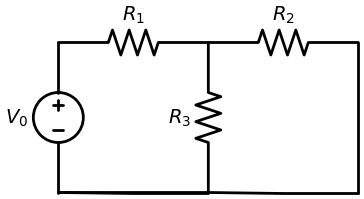

In [19]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    d += elm.SourceV().up().label('$V_0$')
    d += elm.Resistor().right().label('$R_1$')
    d.push()
    d += elm.Resistor().down().label('$R_3$')
    d += elm.Line().left()
    d.pop()
    d += elm.Resistor().right().label('$R_2$')
    d += elm.Line().down()
    d += elm.Line().left()
    d += elm.Line().left()